# Task 4: Model Development

This is where we actually train something. We take the labelled table from Notebook 3, try a few standard classifiers, pick the one that ranks best, tune it, and check it on data it hasn't seen. Anything we'll need again in Notebook 5 (the fitted model, the test split, the metrics) gets saved at the end.


In [2]:
from pathlib import Path
from typing import cast
import json
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate,
    RandomizedSearchCV, ParameterGrid
)
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
)
import warnings
# Import XGBoost/LightGBM safely — if the compiled libs (e.g. libomp) are missing
# importing XGBoost can raise a runtime error on macOS. Fall back gracefully.
try:
    from xgboost import XGBClassifier
except Exception as e:
    XGBClassifier = None
    _xgb_import_error = e
    warnings.warn(f'XGBoost import failed: {e}. XGBoost models will be skipped.' )
try:
    from lightgbm import LGBMClassifier
except Exception as e:
    LGBMClassifier = None
    _lgb_import_error = e
    warnings.warn(f'LightGBM import failed: {e}. LightGBM models will be skipped.' )

import joblib


/var/folders/q3/zf1f5qpn4pbgdc87x5y921nr0000gn/T/ipykernel_6386/2259004871.py:29: UserWarning: XGBoost import failed: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Users/avisorghosh/Documents/Projects/OnlineRetailCustomerChurnAnalysis/.venv/lib/python3.13/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <4E82201A-ED82-3451-AD25-7886C77941A1> /Users/avisorghosh/Documents/Projects/OnlineRetailCustomerChurnAnalysis/.venv/lib/python3.13/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes

In [3]:
BASE_DIR = Path.cwd()
model_file = BASE_DIR / 'modeling_dataset.csv'

if not model_file.exists():
    raise FileNotFoundError('Please run Notebook 3 first to generate modeling_dataset.csv')

df = pd.read_csv(model_file, parse_dates=['first_purchase', 'last_purchase', 'snapshot_date'])
print('Loaded modeling rows:', len(df))
df.head()

Loaded modeling rows: 3199


,customer_id,first_purchase,last_purchase,frequency_orders,purchase_lines,monetary_total_spend,total_quantity,unique_products,unique_countries,avg_unit_price,...,return_lines,return_invoices,returned_quantity,return_value,net_spend,return_invoice_ratio,return_value_ratio,future_orders,churn_label,snapshot_date
0,12346,2010-03-02 13:08:00,2010-06-28 13:53:00,2,24,169.36,24,24,1,7.056667,...,1.0,1.0,1.0,103.50,65.86,0.5,0.611124,0,1,2010-08-11
1,12349,2010-04-29 13:20:00,2010-04-29 13:20:00,1,46,1068.52,473,46,1,4.230000,...,5.0,1.0,5.0,24.15,1044.37,1.0,0.022601,1,0,2010-08-11
2,12355,2010-05-21 11:59:00,2010-05-21 11:59:00,1,22,488.21,303,22,1,2.399091,...,0.0,0.0,0.0,0.00,488.21,0.0,0.000000,0,1,2010-08-11
3,12358,2009-12-08 07:59:00,2010-06-07 12:28:00,2,35,1697.93,590,34,1,3.442571,...,0.0,0.0,0.0,0.00,1697.93,0.0,0.000000,1,0,2010-08-11
4,12359,2009-12-05 13:32:00,2010-06-22 10:24:00,5,86,2012.03,877,82,1,5.170349,...,4.0,2.0,216.0,94.00,1918.03,0.4,0.046719,1,0,2010-08-11


## Pick features and target

Notebook 3 already built the features, so here we just split off the target and drop the columns that aren't predictors (the id, the dates, the snapshot, and `future_orders`, which is what the label was derived from). Everything left is numeric, so the categorical branch of the preprocessor ends up empty.


In [4]:
# Select feature columns and target
target = 'churn_label'
drop_cols = ['customer_id', 'churn_label', 'future_orders', 'snapshot_date', 'first_purchase', 'last_purchase']
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols].copy()
y = df[target].astype(int)

# Infer numeric/categorical feature groups
numeric_features = X.select_dtypes(include=['number']).columns.tolist()
categorical_features = X.select_dtypes(exclude=['number']).columns.tolist()

print('Numeric features:', len(numeric_features))
print('Categorical features:', len(categorical_features))

Numeric features: 28
Categorical features: 0


## Split and preprocessing

We hold out 20% for a final test and keep the class balance the same on both sides. The preprocessing (median impute + scaling for numbers, with a one-hot path ready in case any categoricals show up) lives inside a pipeline so it's fit on the training folds only and never peeks at the test data.


In [5]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Shared preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

## Baseline models

Six candidates: logistic regression and random forest as the interpretable/robust pair, then four boosting variants - sklearn's `GradientBoosting` and `HistGradientBoosting`, plus `XGBoost` and `LightGBM`, which are usually the strongest off-the-shelf models on tabular data. Each runs through 5-fold stratified cross-validation. We log precision, recall, F1 and ROC-AUC, but since the point is to catch churners (the positive class), recall is the one to keep an eye on. Every model gets class-imbalance handling (`class_weight='balanced'`, or `scale_pos_weight` for XGBoost) to offset the lighter churn class.


In [6]:
# XGBoost has no class_weight, so we weight the positive class manually.
neg, pos = int((y_train == 0).sum()), int((y_train == 1).sum())
scale_pos_weight = neg / pos

# Baseline model zoo
models = {
    'logistic_regression': LogisticRegression(max_iter=300, class_weight='balanced', random_state=42),
    'random_forest': RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1),
    'gradient_boosting': GradientBoostingClassifier(random_state=42),
    'hist_gradient_boosting': HistGradientBoostingClassifier(class_weight='balanced', random_state=42),
}
# Add XGBoost if available
if 'XGBClassifier' in globals() and XGBClassifier is not None:
    models['xgboost'] = XGBClassifier(
        n_estimators=300, learning_rate=0.1, max_depth=4, subsample=0.9, colsample_bytree=0.9,
        scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=42, n_jobs=-1
    )
else:
    print('XGBoost not available — skipping xgboost baseline. On macOS run: brew install libomp')

# Add LightGBM if available
if 'LGBMClassifier' in globals() and LGBMClassifier is not None:
    models['lightgbm'] = LGBMClassifier(
        n_estimators=300, learning_rate=0.05, class_weight='balanced',
        random_state=42, n_jobs=-1, verbose=-1
    )
else:
    print('LightGBM not available — skipping lightgbm baseline.')

scoring = {
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, model in models.items():
    pipe = Pipeline(steps=[('prep', preprocessor), ('model', model)])
    cv_res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

    results.append({
        'model': name,
        'cv_precision_mean': np.mean(cv_res['test_precision']),
        'cv_recall_mean': np.mean(cv_res['test_recall']),
        'cv_f1_mean': np.mean(cv_res['test_f1']),
        'cv_roc_auc_mean': np.mean(cv_res['test_roc_auc'])
    })

results_df = pd.DataFrame(results).sort_values('cv_roc_auc_mean', ascending=False).reset_index(drop=True)
display(results_df)


XGBoost not available — skipping xgboost baseline. On macOS run: brew install libomp
LightGBM not available — skipping lightgbm baseline.


,model,cv_precision_mean,cv_recall_mean,cv_f1_mean,cv_roc_auc_mean
0,logistic_regression,0.529297,0.725527,0.611673,0.737710
1,random_forest,0.544153,0.600657,0.570392,0.732510
2,gradient_boosting,0.562276,0.486550,0.521152,0.724552
3,hist_gradient_boosting,0.529599,0.594182,0.559553,0.709110


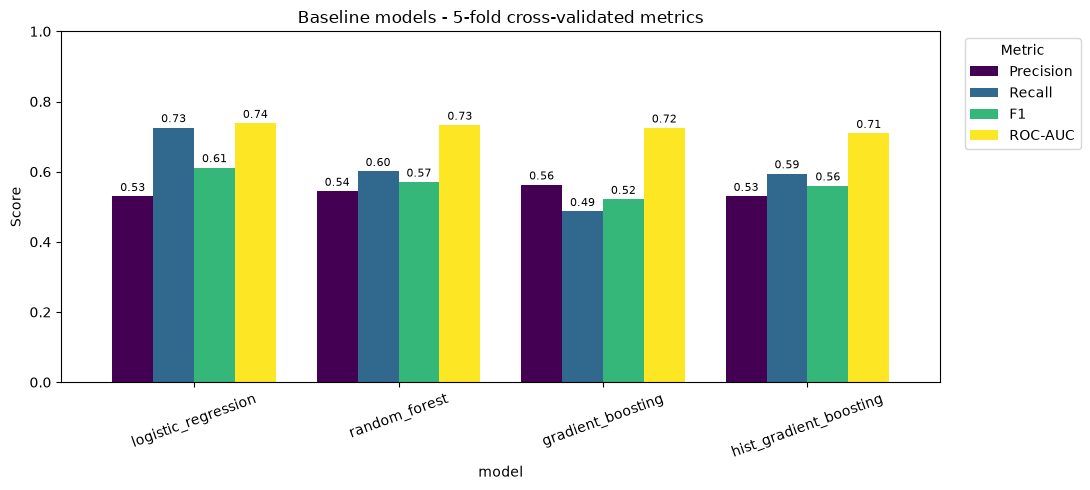

In [7]:
import matplotlib.pyplot as plt
from matplotlib.container import BarContainer

# Compare the six baselines side by side across the four CV metrics.
plot_df = results_df.set_index('model')[
    ['cv_precision_mean', 'cv_recall_mean', 'cv_f1_mean', 'cv_roc_auc_mean']
]
plot_df.columns = ['Precision', 'Recall', 'F1', 'ROC-AUC']

ax = plot_df.plot(kind='bar', figsize=(11, 5), colormap='viridis', rot=20, width=0.8)
ax.set_title('Baseline models - 5-fold cross-validated metrics')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
for container in ax.containers:
    ax.bar_label(cast(BarContainer, container), fmt='%.2f', fontsize=8, padding=2)
plt.tight_layout()
plt.show()


## Tuning the front-runner

Whichever model tops the ROC-AUC table gets a randomized hyperparameter search (still cross-validated). Randomized search keeps the run cheap while covering a decent spread of settings.


In [8]:
# Take whichever baseline ranked top on ROC-AUC and search its hyperparameters.
best_name = results_df.iloc[0]['model']
print('Best baseline model:', best_name)

# A fresh (untuned) estimator and a search space for each model.
base_models = {
    'logistic_regression': LogisticRegression(max_iter=500, class_weight='balanced', random_state=42),
    'random_forest': RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    'gradient_boosting': GradientBoostingClassifier(random_state=42),
    'hist_gradient_boosting': HistGradientBoostingClassifier(class_weight='balanced', random_state=42),
}
# Add XGBoost if available
if 'XGBClassifier' in globals() and XGBClassifier is not None:
    base_models['xgboost'] = XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=42, n_jobs=-1)
else:
    print('XGBoost not available — skipping xgboost tuning. On macOS run: brew install libomp')

# Add LightGBM if available
if 'LGBMClassifier' in globals() and LGBMClassifier is not None:
    base_models['lightgbm'] = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1)
else:
    print('LightGBM not available — skipping lightgbm tuning.')

param_grids = {
    'logistic_regression': {
        'model__C': [0.01, 0.1, 1, 5, 10],
        'model__solver': ['lbfgs', 'liblinear'],
    },
    'random_forest': {
        'model__n_estimators': [200, 300, 500, 700],
        'model__max_depth': [None, 5, 8, 12, 20],
        'model__min_samples_split': [2, 5, 10, 20],
        'model__min_samples_leaf': [1, 2, 4, 8],
        'model__max_features': ['sqrt', 'log2', None],
    },
    'gradient_boosting': {
        'model__n_estimators': [100, 200, 300],
        'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
        'model__max_depth': [2, 3, 4],
        'model__subsample': [0.6, 0.8, 1.0],
    },
    'hist_gradient_boosting': {
        'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
        'model__max_iter': [200, 300, 500],
        'model__max_leaf_nodes': [15, 31, 63],
        'model__l2_regularization': [0.0, 0.1, 1.0],
    },
    'xgboost': {
        'model__n_estimators': [200, 300, 500],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__max_depth': [3, 4, 6],
        'model__subsample': [0.7, 0.9, 1.0],
        'model__colsample_bytree': [0.7, 0.9, 1.0],
    },
    'lightgbm': {
        'model__n_estimators': [200, 300, 500],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__num_leaves': [15, 31, 63],
        'model__subsample': [0.7, 0.9, 1.0],
        'model__colsample_bytree': [0.7, 0.9, 1.0],
    },
}

base_model = base_models[best_name]
param_dist = param_grids[best_name]

tuning_pipeline = Pipeline(steps=[('prep', preprocessor), ('model', base_model)])

# Don't ask for more random draws than the grid actually has (avoids the
# "n_iter larger than search space" warning when the grid is small).
n_iter = min(25, len(ParameterGrid(param_dist)))

search = RandomizedSearchCV(
    estimator=tuning_pipeline,
    param_distributions=param_dist,
    n_iter=n_iter,
    scoring='roc_auc',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train, y_train)
print('Best CV ROC-AUC:', round(search.best_score_, 4))
print('Best params:', search.best_params_)


Best baseline model: logistic_regression
XGBoost not available — skipping xgboost tuning. On macOS run: brew install libomp
LightGBM not available — skipping lightgbm tuning.
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best CV ROC-AUC: 0.7384
Best params: {'model__solver': 'liblinear', 'model__C': 0.01}


## Held-out test

Now the moment of truth: score the tuned model on the 20% we set aside. These numbers are what we report, since they reflect data the model never trained on. Notebook 5 digs into them further.


In [9]:
# Evaluate tuned model on held-out test set
best_model = cast(Pipeline, search.best_estimator_)
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

test_metrics = {
    'precision': precision_score(y_test, y_pred, zero_division=0),
    'recall': recall_score(y_test, y_pred, zero_division=0),
    'f1_score': f1_score(y_test, y_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_prob)
}

display(pd.Series(test_metrics, name='test_metric').to_frame())


,test_metric
precision,0.538217
recall,0.728448
f1_score,0.619048
roc_auc,0.756518


In [10]:
# Persist artifacts for evaluation notebook
joblib.dump(best_model, BASE_DIR / 'best_churn_model.joblib')

metrics_path = BASE_DIR / 'model_test_metrics.json'
with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(test_metrics, f, indent=2)

results_df.to_csv(BASE_DIR / 'baseline_model_comparison.csv', index=False)

# Save split used for final evaluation consistency
train_out = X_train.copy()
train_out['churn_label'] = y_train.values
test_out = X_test.copy()
test_out['churn_label'] = y_test.values
train_out.to_csv(BASE_DIR / 'train_split.csv', index=False)
test_out.to_csv(BASE_DIR / 'test_split.csv', index=False)

print('Saved model and evaluation artifacts.')

Saved model and evaluation artifacts.


## What we saved

For Notebook 5 to pick up:

- `best_churn_model.joblib` — the tuned pipeline (preprocessing + model in one object)
- `model_test_metrics.json` — the held-out scores
- `baseline_model_comparison.csv` — the six-model CV table
- `train_split.csv` / `test_split.csv` — the exact split, so evaluation lines up with what was trained here
